In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

In [39]:
file_2023 = "DATA TABLE-2023- SALE 50.xlsx"
file_2024 = "DATA TABLE-2024- SALE  51.xlsx"
file_2025 = "DATA TABLE-2025- SALE  46- up to November.xlsx"

df_2023 = pd.read_excel(file_2023, sheet_name="DATA")
df_2024 = pd.read_excel(file_2024, sheet_name="DATA")
df_2025 = pd.read_excel(file_2025, sheet_name="DATA")

df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)
print("df_all:", df_all.shape)

df_all: (1503888, 33)


In [40]:
df_2023.head()

,YEAR,MONTH,BROKER,LOT NO,SALE NO,INV NO,MF,REF,MARK,SALE TYPE,...,BUYER CODE,BUYER NAME,CHEST,CATEGORY,MF/BF,MFREF,FACTORY,ELE1,ELE2,GROUP
0,2023,JAN,AS,1,1,414,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
1,2023,JAN,AS,2,1,415,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
2,2023,JAN,AS,4,1,66,MF,62,KELANEIYA & BRAEMAR,PUBLIC AUCTION,...,S080,SUNSHINE CONSUMER LANKA,10.0,EX-ESTATE,MF,MF0062,KELANEIYA,High,WH,0
3,2023,JAN,AS,5,1,248R,MF,1003,SHANNON,PUBLIC AUCTION,...,D332,DILMA CEYLON TEA CO PLC,10.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0
4,2023,JAN,AS,7,1,235R,MF,1003,SHANNON,PUBLIC AUCTION,...,U102,UNI WORLD TEAS (PVT) LT,20.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0


In [41]:
df_all.head()

,YEAR,MONTH,BROKER,LOT NO,SALE NO,INV NO,MF,REF,MARK,SALE TYPE,...,ELE1,ELE2,GROUP,PLANTATION,COMB. ELEV.,AGRO,CTC/ORTHODOX,DENSITY,CODE,density2
0,2023,JAN,AS,1,1,414,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,Medium,WM,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,JAN,AS,2,1,415,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,Medium,WM,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,JAN,AS,4,1,66,MF,62,KELANEIYA & BRAEMAR,PUBLIC AUCTION,...,High,WH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,JAN,AS,5,1,248R,MF,1003,SHANNON,PUBLIC AUCTION,...,High,WH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,JAN,AS,7,1,235R,MF,1003,SHANNON,PUBLIC AUCTION,...,High,WH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_all.columns.tolist()

['YEAR',
 'MONTH',
 'BROKER',
 'LOT NO',
 'SALE NO',
 'INV NO',
 'MF',
 'REF',
 'MARK',
 'SALE TYPE',
 'GRADE',
 'QTY',
 'PRICE',
 'PRO',
 'TYPE',
 'ELE',
 'BUYER CODE',
 'BUYER NAME',
 'CHEST',
 'CATEGORY',
 'MF/BF',
 'MFREF',
 'FACTORY',
 'ELE1',
 'ELE2',
 'GROUP',
 'PLANTATION',
 'COMB. ELEV.',
 'AGRO',
 'CTC/ORTHODOX',
 'DENSITY',
 'CODE',
 'density2']

In [43]:
# 2) Auto-detect columns

In [44]:
def find_col(df, candidates):
    cols_upper = {c.upper(): c for c in df.columns}
    for cand in candidates:
        if cand.upper() in cols_upper:
            return cols_upper[cand.upper()]
    return None

col_year  = find_col(df_all, ["YEAR", "YR"])
col_sale  = find_col(df_all, ["SALE NO", "SALE_NO", "SALENO", "SALE"])
col_grade = find_col(df_all, ["GRADE", "GRD"])
col_price = find_col(df_all, ["PRICE", "AVG_PRICE", "AVG PRICE", "AVERAGE PRICE"])
col_qty   = find_col(df_all, ["QTY", "QUANTITY", "QTY SOLD", "QTY_SOLD"])
col_ele   = find_col(df_all, ["ELE1", "ELEVATION", "ELEV", "ELE"])

print("Detected columns ->",
      "YEAR:", col_year, "| SALE:", col_sale, "| GRADE:", col_grade,
      "| PRICE:", col_price, "| QTY:", col_qty, "| ELE:", col_ele)

missing = [name for name, v in [("YEAR", col_year), ("SALE", col_sale), ("GRADE", col_grade), ("PRICE", col_price), ("ELE", col_ele)] if v is None]
if missing:
    raise ValueError(f"Missing required columns in your file: {missing}. Print df_all.columns and map manually.")

# Standardize names
df = df_all.rename(columns={
    col_year: "YEAR",
    col_sale: "SALE_NO",
    col_grade: "GRADE",
    col_price: "PRICE",
    col_ele: "ELE1",
    **({col_qty: "QTY"} if col_qty is not None else {})
}).copy()

Detected columns -> YEAR: YEAR | SALE: SALE NO | GRADE: GRADE | PRICE: PRICE | QTY: QTY | ELE: ELE1


In [45]:
# 3) Clean + create week_id + elevation/grade

In [46]:
df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
df["SALE_NO"] = pd.to_numeric(df["SALE_NO"], errors="coerce")
df["PRICE"] = pd.to_numeric(df["PRICE"], errors="coerce")
if "QTY" in df.columns:
    df["QTY"] = pd.to_numeric(df["QTY"], errors="coerce")

df = df.dropna(subset=["YEAR", "SALE_NO", "GRADE", "PRICE", "ELE1"]).copy()

# week_id = YYYYSS (example: 202401)
df["week_id"] = (df["YEAR"].astype(int) * 100) + (df["SALE_NO"].astype(int))

# elevation mapping
df["elevation"] = df["ELE1"].astype(str).str.strip().str.title()
df["elevation"] = df["elevation"].replace({"Medium": "Mid"})  # optional
df["grade"] = df["GRADE"].astype(str).str.strip().str.upper()

In [47]:
# 4) Filter ONLY LOW elevation

In [48]:
df_low = df[df["elevation"] == "Low"].copy()
print("df_low:", df_low.shape)

df_low: (1018754, 36)


In [49]:
# 5) Weekly aggregation (Low × Grade × Week)

In [50]:
if "QTY" in df_low.columns:
    weekly_low = (
        df_low.groupby(["week_id", "grade"], as_index=False)
        .agg(
            qty_sold=("QTY", "sum"),
            value=("PRICE", lambda s: np.nan)  # placeholder
        )
    )

    # compute value = sum(price*qty) safely
    tmp = df_low.copy()
    tmp["PQ"] = tmp["PRICE"] * tmp["QTY"]
    value_df = tmp.groupby(["week_id", "grade"], as_index=False).agg(
        value=("PQ", "sum"),
        qty_sold=("QTY", "sum")
    )
    value_df["avg_price"] = value_df["value"] / value_df["qty_sold"].replace(0, np.nan)

    weekly_low = value_df[["week_id","grade","avg_price","qty_sold"]].sort_values(["week_id","grade"])
else:
    weekly_low = (
        df_low.groupby(["week_id","grade"], as_index=False)
        .agg(avg_price=("PRICE","mean"))
        .sort_values(["week_id","grade"])
    )


In [51]:
# Count real observed weeks per grade (before interpolation)
real_counts = (weekly_low.dropna(subset=["avg_price"])
               .groupby("grade")["week_id"]
               .nunique()
               .rename("real_weeks")
               .reset_index())

real_counts.sort_values("real_weeks").head(20)


,grade,real_weeks
58,LADALU CHA,1
98,ORG FT BP,1
97,ORG FT BM,1
95,ORG FBOP1,1
23,EB,1
64,OB PEK,1
45,GT-BOP,1
19,CIN STICKS,1
44,GT SENCHA,1
68,OG BT FNGS,1


In [52]:
# 6) Build a REAL calendar of sale weeks (no fake weeks between years)

In [53]:
cal = (weekly_low[["week_id"]]
       .drop_duplicates()
       .assign(YEAR=lambda d: (d["week_id"] // 100).astype(int),
               SALE=lambda d: (d["week_id"] % 100).astype(int))
       .sort_values(["YEAR", "SALE"])
       .reset_index(drop=True))

cal["t"] = np.arange(len(cal))

# Synthetic weekly dates (supported index)
start_date = pd.Timestamp(f"{cal['YEAR'].min()}-01-05")  # arbitrary start
cal["date"] = start_date + pd.to_timedelta(cal["t"], unit="W")

cal.head()

,week_id,YEAR,SALE,t,date
0,202301,2023,1,0,2023-01-05
1,202302,2023,2,1,2023-01-12
2,202303,2023,3,2,2023-01-19
3,202304,2023,4,3,2023-01-26
4,202305,2023,5,4,2023-02-02


In [54]:
# 7) Build a grade series aligned to the calendar (fills missing)

In [55]:
def build_low_series(weekly_low, grade, cal):
    g = weekly_low[weekly_low["grade"] == grade].copy()
    g = g.merge(cal[["week_id","date"]], on="week_id", how="right").sort_values("date")

    # No leakage: use forward-fill, then optional small backfill at start
    g["avg_price"] = g["avg_price"].ffill().bfill()

    y = g.set_index("date")["avg_price"].astype(float)
    return y


In [56]:
# 8) Safe metrics (never crash on NaN)

In [57]:
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return np.nan, np.nan, np.nan

    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100)
    return mae, rmse, mape


In [58]:
# 9) Fit SARIMAX for one grade series (stable indexing)

In [59]:
def fit_one_grade_series_fixed_test(
    y,
    test_size=52,
    order=(1,1,1),
    seasonal_order=(1,0,1,52)
):
    y = y.sort_index().astype(float).dropna()
    if len(y) <= test_size + 10:
        return None

    y_train = y.iloc[:-test_size]
    y_test  = y.iloc[-test_size:]

    try:
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=200)

        fc = model.get_forecast(steps=test_size)
        y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)

        mae, rmse, mape = calc_metrics(y_test.values, y_pred.values)

        return {
            "model": model,
            "y_full": y,
            "y_train": y_train,
            "y_test": y_test,
            "y_pred_test": y_pred,
            "mae": mae,
            "rmse": rmse,
            "mape": mape,
            "order": order,
            "seasonal_order": seasonal_order
        }
    except Exception as e:
        print("Fit failed:", e)
        return None


In [60]:
# 10) Train SARIMAX for ALL grades (LOW)

In [61]:
models_low = {}
rows = []

MIN_REAL_WEEKS = 120    # was 80
MIN_STD = 5.0
TEST_SIZE = 52          # was 20

real_weeks_map = dict(zip(real_counts["grade"], real_counts["real_weeks"]))

for grade in sorted(weekly_low["grade"].dropna().unique()):
    real_weeks = real_weeks_map.get(grade, 0)
    if real_weeks < MIN_REAL_WEEKS:
        continue

    y = build_low_series(weekly_low, grade, cal)

    if float(np.nanstd(y.values)) < MIN_STD:
        continue

    info = fit_one_grade_series_fixed_test(y, test_size=TEST_SIZE)
    if info is None or not np.isfinite(info["mae"]):
        continue

    models_low[grade] = info
    rows.append([grade, real_weeks, info["mae"], info["rmse"], info["mape"], len(info["y_full"]), str(info["seasonal_order"])])
    print(f"[LOW] {grade} | real_weeks={real_weeks} | MAE={info['mae']:.2f} RMSE={info['rmse']:.2f} MAPE={info['mape']:.2f}%")

metrics_low = (pd.DataFrame(rows, columns=["grade","real_weeks","MAE","RMSE","MAPE_%","n_weeks","seasonal_order"])
                 .sort_values("MAPE_%"))

metrics_low.head(30)


[LOW] BM | real_weeks=147 | MAE=91.17 RMSE=98.55 MAPE=10.83%
[LOW] BOP | real_weeks=147 | MAE=107.16 RMSE=139.74 MAPE=7.95%
[LOW] BOP1 | real_weeks=147 | MAE=75.54 RMSE=106.75 MAPE=4.82%
[LOW] BOP1A | real_weeks=147 | MAE=126.16 RMSE=130.74 MAPE=13.97%
[LOW] BOPA | real_weeks=147 | MAE=103.73 RMSE=128.95 MAPE=7.94%
[LOW] BOPF | real_weeks=147 | MAE=60.99 RMSE=72.73 MAPE=6.28%
[LOW] BOPFSP | real_weeks=147 | MAE=167.87 RMSE=189.49 MAPE=13.54%
[LOW] BOPSP | real_weeks=147 | MAE=156.51 RMSE=180.70 MAPE=11.19%
[LOW] BP | real_weeks=147 | MAE=80.26 RMSE=88.58 MAPE=8.71%
[LOW] BP1 | real_weeks=147 | MAE=63.70 RMSE=85.14 MAPE=6.61%
[LOW] BT | real_weeks=147 | MAE=112.81 RMSE=130.25 MAPE=13.35%
[LOW] DUST | real_weeks=147 | MAE=27.03 RMSE=36.41 MAPE=3.51%
[LOW] DUST1 | real_weeks=147 | MAE=45.79 RMSE=58.98 MAPE=5.29%
[LOW] FBOP | real_weeks=147 | MAE=42.05 RMSE=56.35 MAPE=2.83%
[LOW] FBOP1 | real_weeks=147 | MAE=72.68 RMSE=93.70 MAPE=5.48%
[LOW] FBOPF | real_weeks=147 | MAE=151.48 RMSE=174.87 

,grade,real_weeks,MAE,RMSE,MAPE_%,n_weeks,seasonal_order
20,FGS,147,19.554754,22.837326,2.455595,147,"(1, 0, 1, 52)"
13,FBOP,147,42.054131,56.347646,2.828213,147,"(1, 0, 1, 52)"
11,DUST,147,27.027140,36.409991,3.512915,147,"(1, 0, 1, 52)"
27,PEK,147,50.693520,64.251575,3.569735,147,"(1, 0, 1, 52)"
26,PD,147,38.833825,48.769941,3.613649,147,"(1, 0, 1, 52)"
23,OP,147,48.840433,61.417260,3.806524,147,"(1, 0, 1, 52)"
21,FGS1,147,30.666463,39.569999,3.859311,147,"(1, 0, 1, 52)"
29,PF,147,31.790921,38.280873,4.217459,147,"(1, 0, 1, 52)"
2,BOP1,147,75.540964,106.750442,4.821372,147,"(1, 0, 1, 52)"
16,FBOPF1,147,65.953387,84.111825,4.973233,147,"(1, 0, 1, 52)"


In [62]:
# 11) Validation plot (LOW) for any grade

In [63]:
def plot_validation_low(grade):
    info = models_low[grade]
    y_full = info["y_full"]
    y_test = info["y_test"]
    y_pred = info["y_pred_test"]

    plt.figure(figsize=(12,4))
    plt.plot(y_full.index, y_full.values, color="lightgray", label="Full series (history)")
    plt.plot(y_test.index, y_test.values, linewidth=2, label="Test (actual)")
    plt.plot(y_pred.index, y_pred.values, linewidth=2, label="Test (pred)")
    plt.title(f"LOW – {grade} | MAE={info['mae']:.2f} RMSE={info['rmse']:.2f} MAPE={info['mape']:.2f}%")
    plt.xlabel("Week")
    plt.ylabel("Avg Price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()

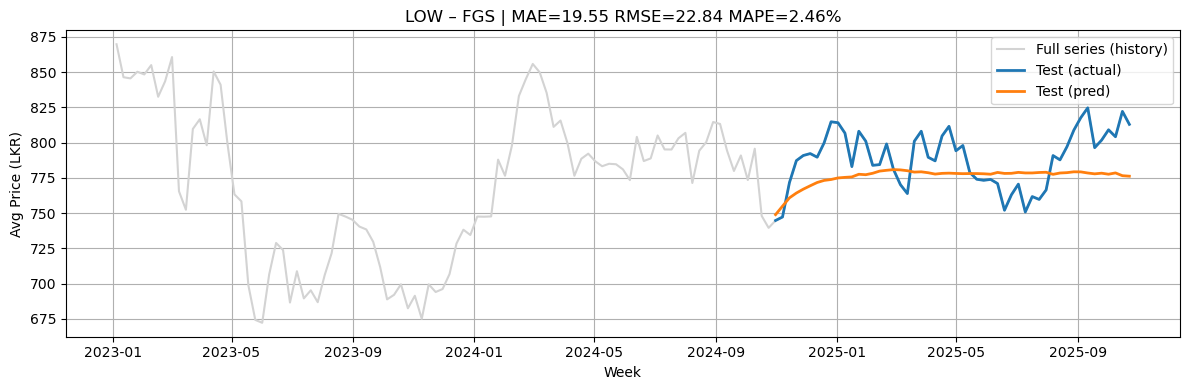

In [64]:
best_grade = metrics_low.iloc[0]["grade"]
plot_validation_low(best_grade)

In [65]:
# 12) Residual diagnostics (LOW)

In [66]:
def residual_diagnostics_low(grade, lags=40):
    info = models_low[grade]
    resid = (info["y_test"] - info["y_pred_test"]).astype(float)

    # drop NaNs/inf
    resid = resid.replace([np.inf, -np.inf], np.nan).dropna()

    if len(resid) < 5:
        print(f"Not enough residual points to plot ACF (n={len(resid)}).")
        return

    # cap lags to a safe value
    max_lags = min(lags, len(resid) - 2, 30)   # 30 is a nice upper limit for readability
    if max_lags < 1:
        print(f"Not enough data for ACF (n={len(resid)}).")
        return

    plt.figure(figsize=(12,3))
    plt.plot(resid.index, resid.values)
    plt.title(f"LOW – {grade}: Residuals over time (Test) | n={len(resid)}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12,3))
    plot_acf(resid.values, lags=max_lags)
    plt.title(f"LOW – {grade}: Residual ACF (Test) | lags={max_lags}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(resid.values, bins=20)
    plt.title(f"LOW – {grade}: Residual distribution (Test)")
    plt.tight_layout()
    plt.show()


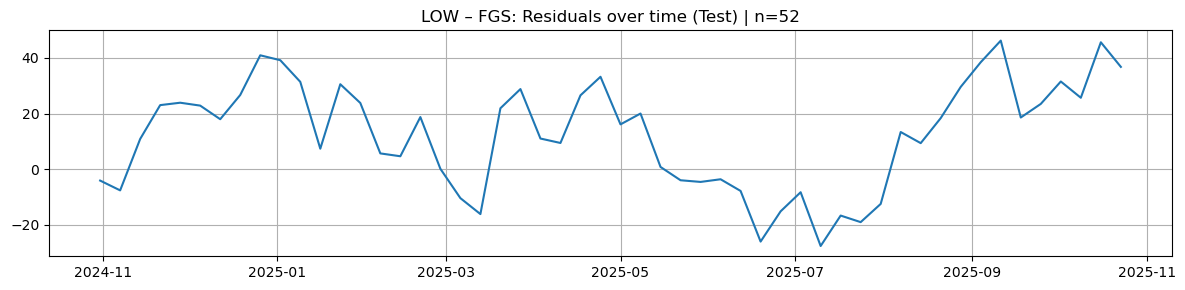

<Figure size 1200x300 with 0 Axes>

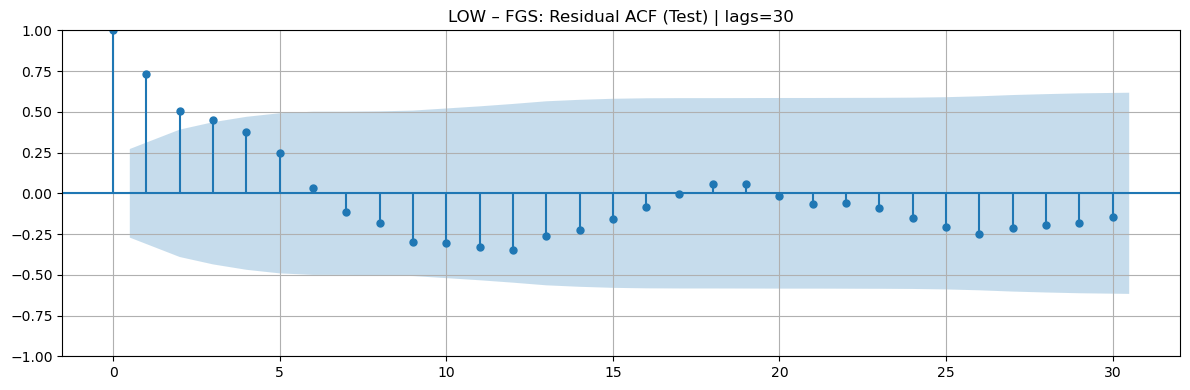

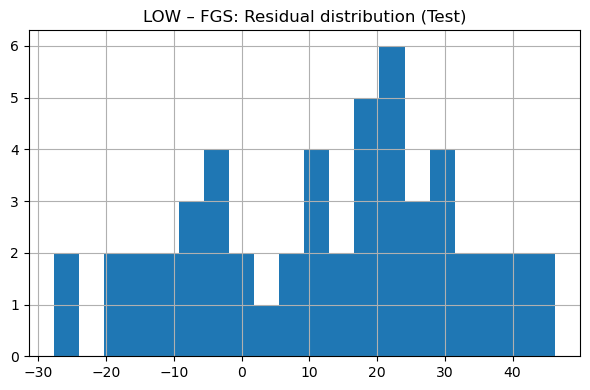

In [67]:
residual_diagnostics_low(best_grade, lags=40)


In [68]:
# 13) Future forecast plot (LOW) + confidence interval

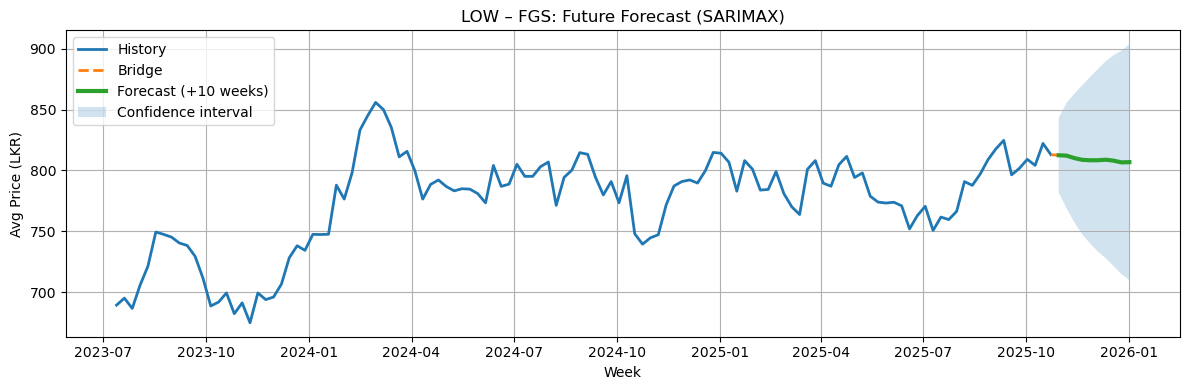

2025-10-30    812.453513
2025-11-06    812.147025
2025-11-13    810.126687
2025-11-20    808.706589
2025-11-27    808.362885
2025-12-04    808.378594
2025-12-11    808.817057
2025-12-18    808.013244
2025-12-25    806.610127
2026-01-01    806.815373
Freq: W-THU, Name: predicted_mean, dtype: float64

In [69]:
def forecast_future_low(grade, steps=10, show_last=120, connect=True):
    info = models_low[grade]
    y = info["y_full"]

    model_full = SARIMAX(
        y,
        order=info["order"],
        seasonal_order=info["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=200)

    fc = model_full.get_forecast(steps=steps)
    y_fc = fc.predicted_mean
    ci = fc.conf_int()

    # zoom last part of history for visibility
    y_plot = y.iloc[-show_last:] if len(y) > show_last else y

    plt.figure(figsize=(12,4))
    plt.plot(y_plot.index, y_plot.values, linewidth=2, label="History")

    # connector so forecast looks continuous from last history point
    if connect and len(y_fc) > 0:
        x0 = y_plot.index[-1]
        y0 = y_plot.iloc[-1]
        x1 = y_fc.index[0]
        y1 = y_fc.iloc[0]
        plt.plot([x0, x1], [y0, y1], linestyle="--", linewidth=2, label="Bridge")

    # forecast as a LINE (no markers)
    plt.plot(y_fc.index, y_fc.values, linewidth=3, label=f"Forecast (+{steps} weeks)")

    plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, label="Confidence interval")

    plt.title(f"LOW – {grade}: Future Forecast (SARIMAX)")
    plt.xlabel("Week")
    plt.ylabel("Avg Price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_fc, ci

y_fc, ci = forecast_future_low(best_grade, steps=10)
y_fc

In [70]:
# 14) Next-week predictions for ALL LOW grades

In [71]:
def next_week_predictions_low(models_low):
    out = []
    for grade, info in models_low.items():
        y = info["y_full"]

        model_full = SARIMAX(
            y,
            order=info["order"],
            seasonal_order=info["seasonal_order"],
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=200)

        next_pred = float(model_full.forecast(steps=1).iloc[0])
        next_date = y.index.max() + pd.to_timedelta(1, unit="W")

        out.append([grade, next_date.date(), next_pred])

    return pd.DataFrame(out, columns=["grade","next_week_date","pred_avg_price"]).sort_values("grade")

df_next_low = next_week_predictions_low(models_low)
df_next_low.head(30)

,grade,next_week_date,pred_avg_price
0,BM,2025-10-30,800.861643
1,BOP,2025-10-30,1558.429050
2,BOP1,2025-10-30,1474.492553
3,BOP1A,2025-10-30,897.438492
4,BOPA,2025-10-30,1412.787998
5,BOPF,2025-10-30,1030.303450
6,BOPFSP,2025-10-30,1350.921459
7,BOPSP,2025-10-30,1578.959978
8,BP,2025-10-30,888.121113
9,BP1,2025-10-30,996.459061


In [72]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_test_low(grade, lags=10):
    info = models_low[grade]
    resid = (info["y_test"] - info["y_pred_test"]).astype(float).dropna()

    lags = min(lags, len(resid)-2)
    lb = acorr_ljungbox(resid, lags=[lags], return_df=True)
    print(f"{grade} Ljung-Box (lag={lags}) p-value =", float(lb["lb_pvalue"].iloc[0]))

ljung_box_test_low("BOP1A", lags=10)


BOP1A Ljung-Box (lag=10) p-value = 3.608599615872001e-21


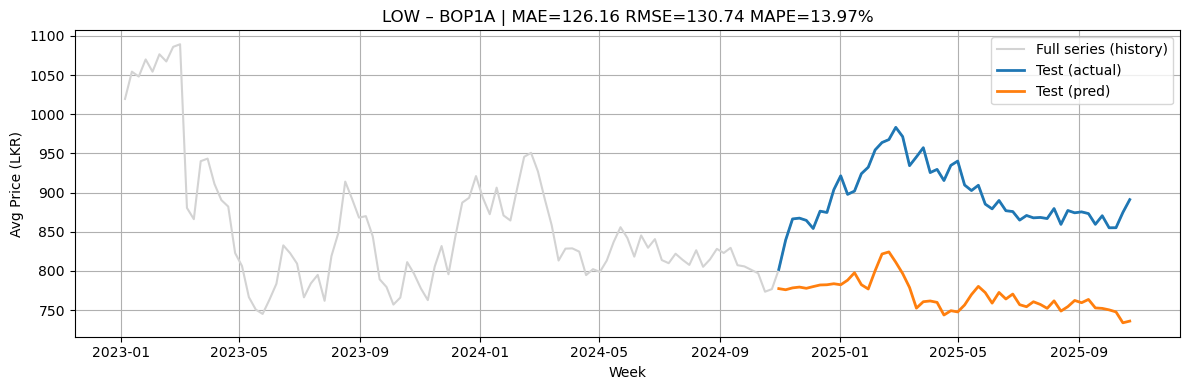

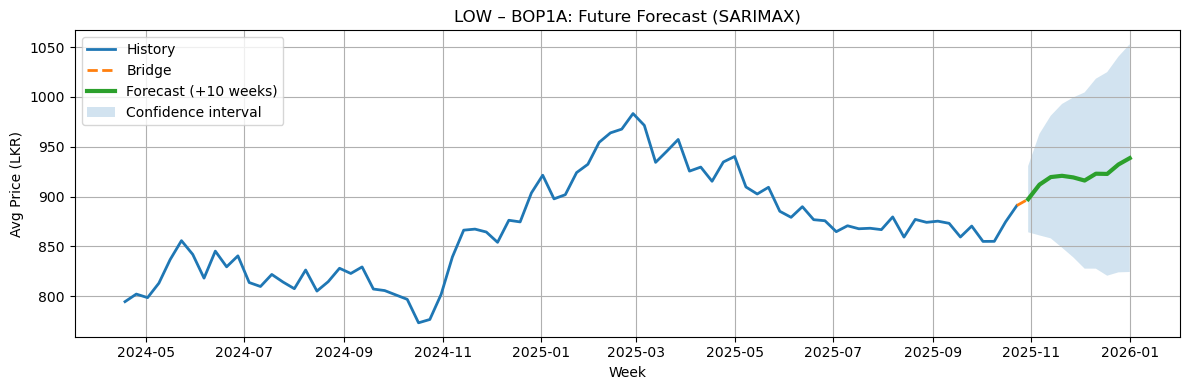

In [73]:
plot_validation_low("BOP1A")
y_fc, ci = forecast_future_low("BOP1A", steps=10, show_last=80, connect=True)

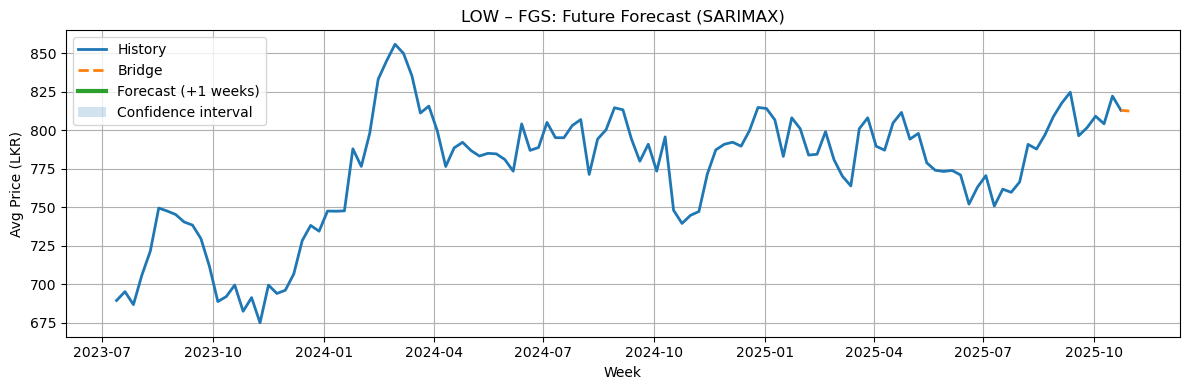

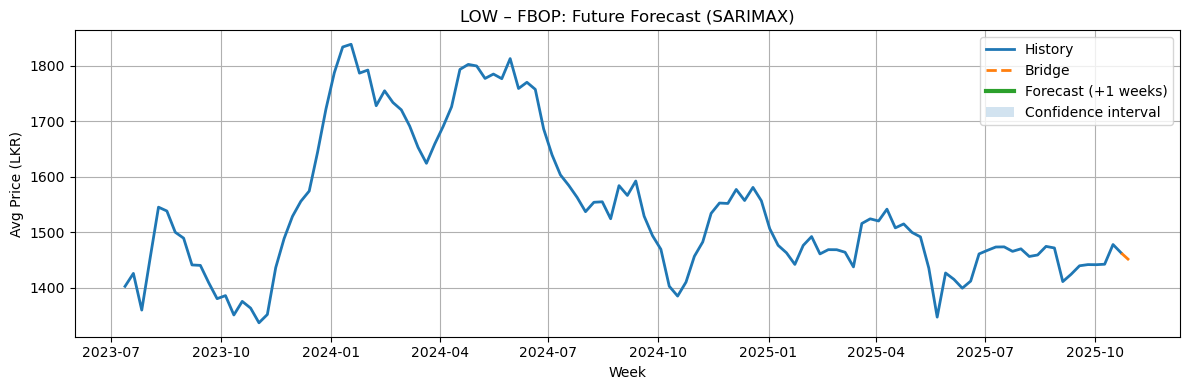

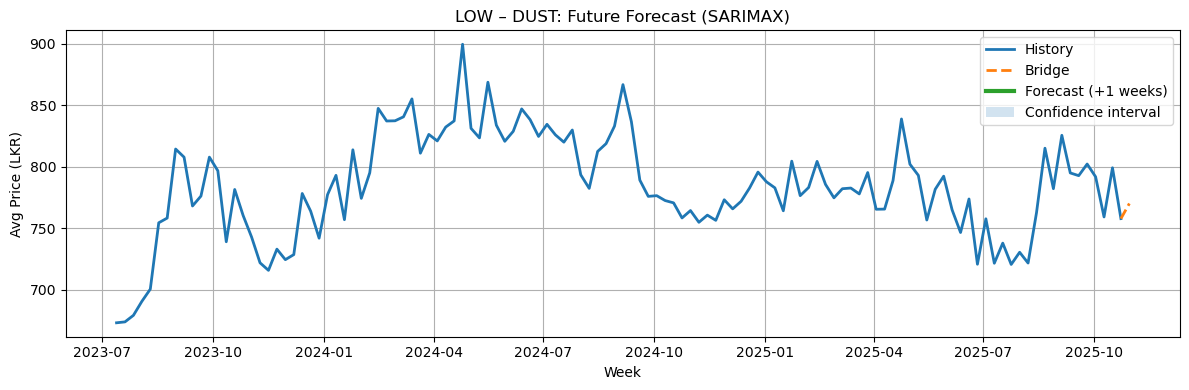

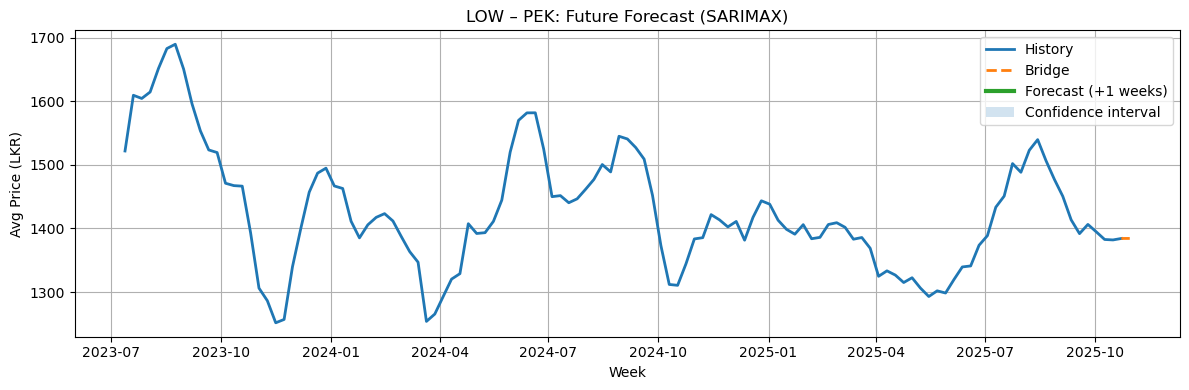

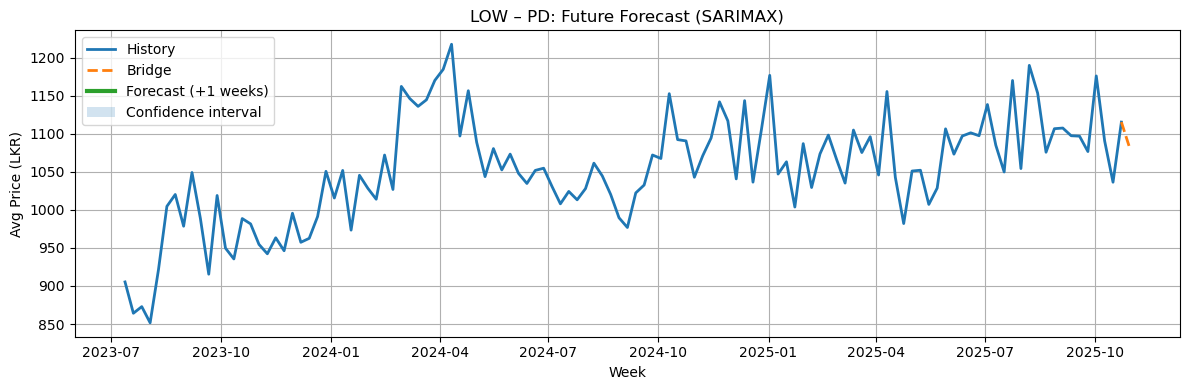

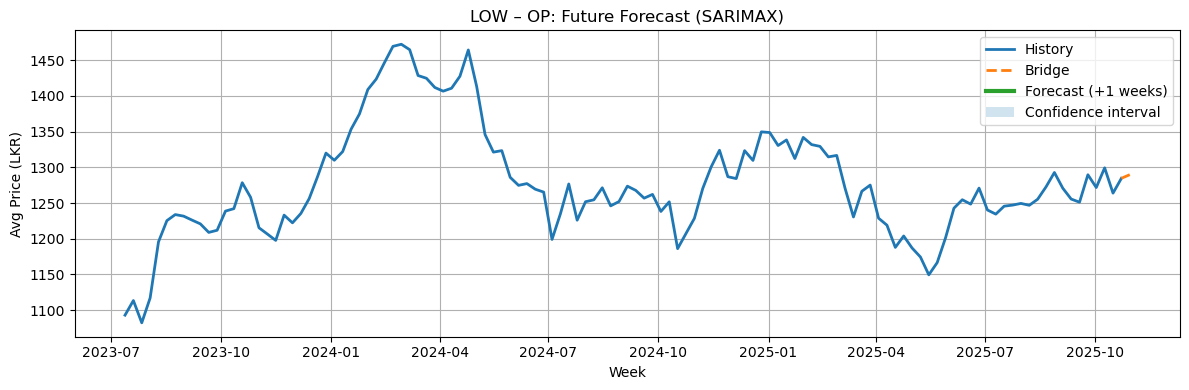

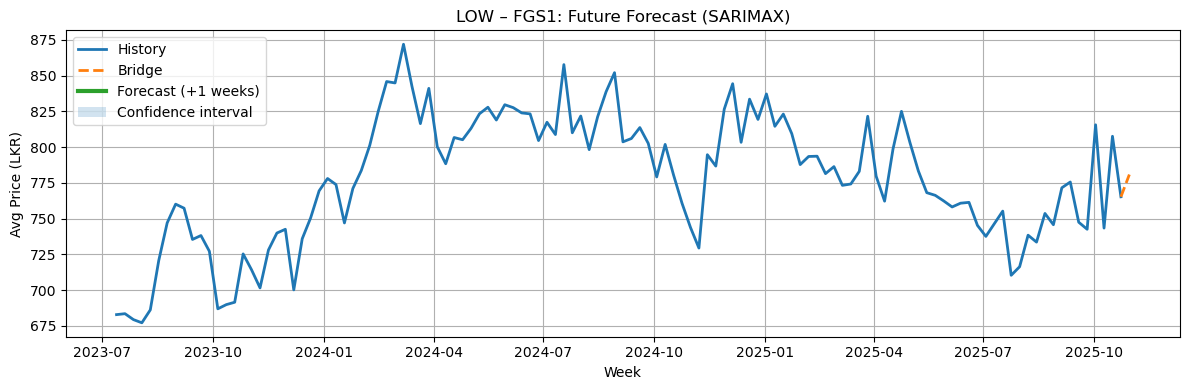

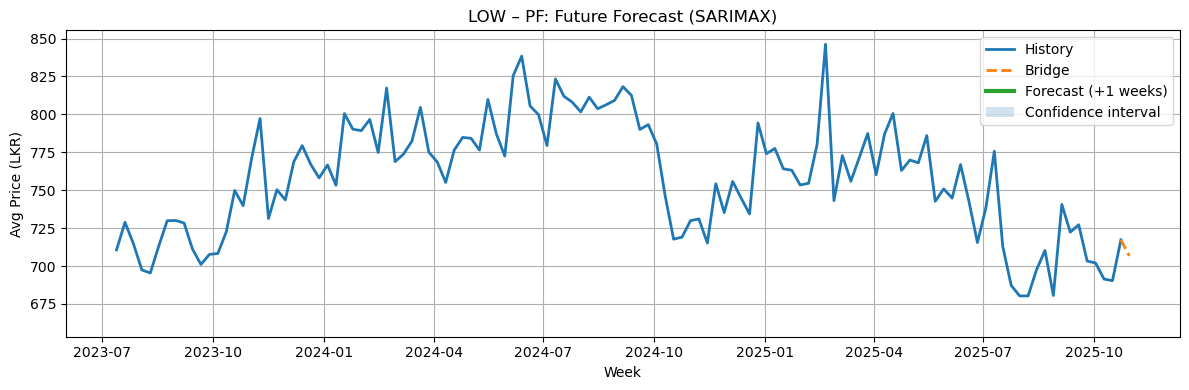

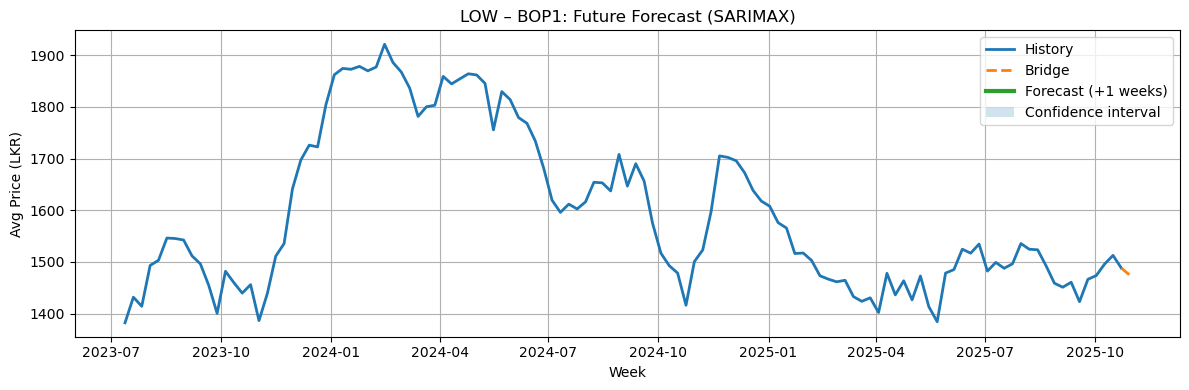

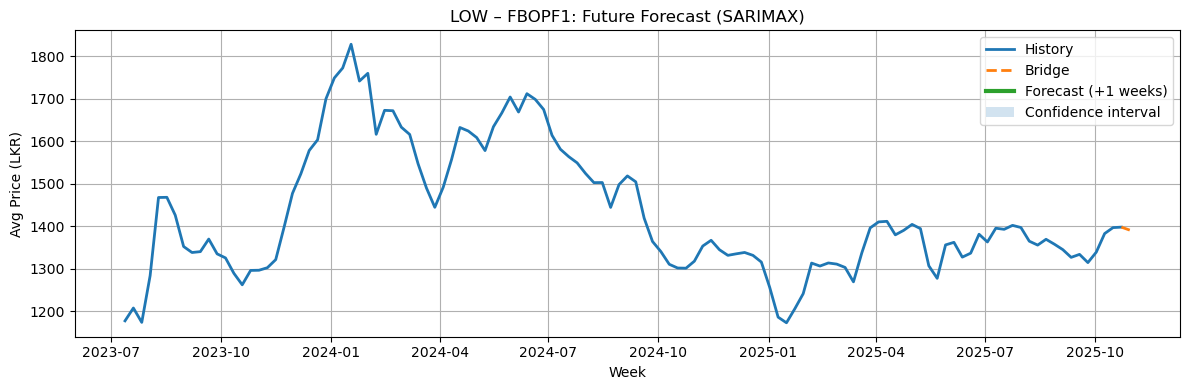

,grade,next_week_pred_price
8,BOP1,1474.492553
1,FBOP,1448.768717
9,FBOPF1,1390.530593
3,PEK,1384.236303
5,OP,1289.689086
4,PD,1080.937479
0,FGS,812.453513
6,FGS1,780.808285
2,DUST,769.935317
7,PF,706.686632


In [74]:
top_grades = metrics_low.head(10)["grade"].tolist()

preds = []
for g in top_grades:
    y_fc, _ = forecast_future_low(g, steps=1)
    preds.append([g, float(y_fc.iloc[0])])

pd.DataFrame(preds, columns=["grade","next_week_pred_price"]).sort_values("next_week_pred_price", ascending=False)


In [75]:
import pickle

# Save ALL low-elevation SARIMAX infos (includes fitted model object inside each grade)
with open("low_elevation_sarimax_models.pkl", "wb") as f:
    pickle.dump(models_low, f)

print("Saved all LOW-elevation SARIMAX models to low_elevation_sarimax_models.pkl")


Saved all LOW-elevation SARIMAX models to low_elevation_sarimax_models.pkl
